In [1]:
import numpy as np
from numpy.fft import ifft2, fftshift
import matplotlib.pyplot as plt
from scipy.linalg import expm, inv
from scipy.optimize import root, minimize_scalar, minimize
import time

theta = 2/5
kappa_aa = 1-theta 
kappa_bb = 1-theta
kappa_ab = -theta
kappa_ba = -theta
Gamma_aa = 1
Gamma_bb = 1
Gamma_ab = 0
Gamma_ba = 0
A_fixedpoint = 0.35
B_fixedpoint = 0.35
D_A = 0.1
D_B = 0.1
D_v = 0.01
Nx = 256
Ny = 256
Lx = 256
Ly = 256
h = 0.1

params = {
    'D_A': D_A, 'D_B': D_B, 'D_v': D_v,
    'beta': 10, 'h': h,
    'kappa_aa' : kappa_aa, 
    'kappa_bb': kappa_bb,
    'kappa_ab' : kappa_ab,
    'kappa_ba' : kappa_ba,
    'Gamma_aa' : Gamma_aa,
    'Gamma_bb': Gamma_bb,
    'Gamma_ab': Gamma_ab,
    'Gamma_ba': Gamma_ba,
    'a0': A_fixedpoint, 'b0': B_fixedpoint
}

# ---------- Functions (linearized model) ----------
def build_L_matrices(params):
    Da, Db, Dv = params['D_A'], params['D_B'], params['D_v']
    kap = np.array([[params['kappa_aa'], params['kappa_ab']],
                    [params['kappa_ba'], params['kappa_bb']]])
    Gam = np.array([[params['Gamma_aa'], params['Gamma_ab']],[params['Gamma_ba'], params['Gamma_bb']]])
    beta = params['beta']
    a0, b0 = params['a0'], params['b0']
    s0 = 1.0 - a0 - b0
    A0 = np.zeros((2,2)); A1 = np.zeros((2,2))
    pref = lambda D, rho: D * beta * s0 * rho

    A0[0,0] = Da*(s0 + a0) + Dv*b0
    A0[1,1] = Db*(s0 + b0) + Dv*a0
    A0[0,1] = Da*a0 - Dv*a0
    A0[1,0] = Db*b0 - Dv*b0

    A0[0,0] -= pref(Da, a0)*kap[0,0]
    A0[0,1] -= pref(Da, a0)*kap[0,1]
    A0[1,0] -= pref(Db, b0)*kap[1,0]
    A0[1,1] -= pref(Db, b0)*kap[1,1]

    A1[0,0] = - pref(Da, a0) * Gam[0,0]
    A1[0,1] = - pref(Da, a0) * Gam[0,1]
    A1[1,0] = - pref(Db, b0) * Gam[1,0]
    A1[1,1] = - pref(Db, b0) * Gam[1,1]

    return A0, A1

def frequency(k, J, Q):
    W = k**2*(J.trace() - k**2* Q.trace())
    adjJ = np.array([[J[1,1],-J[0,1]],[-J[1,0],J[0,0]]])
    Z = k**4*(np.linalg.det(J)-k**2*np.trace(adjJ @ Q) + k**4*np.linalg.det(Q))
    D = 4*Z-W**2
    sqrtD = np.sqrt(D + 0j)
    omega_plus = 1/2*(-1j*W + sqrtD)
    omega_min = 1/2*(-1j*W - sqrtD)
    return omega_plus, omega_min

def rates(k, J, Q):
    om_plus, om_min = frequency(k, J, Q)
    return np.minimum(- om_plus.imag, - om_min.imag)


In [2]:

def optimize_rate(J, Q, k_bounds=(0.1, 5.0)):
    # Minimize the negative of the rate over k
    result = minimize_scalar(rates, bounds=k_bounds, args=(J, Q), method='bounded')
    
    # If successful, return the optimal value of k and the maximum rate
    if result.success:
        optimal_k = result.x
        max_rate = -result.fun  # Since we minimized the negative rate
        return optimal_k, max_rate
    else:
        raise ValueError("Optimization failed.")

{'D_A': 0.1, 'D_B': 0.1, 'D_v': 0.01, 'beta': 10, 'h': 0.1, 'kappa_aa': 0.6, 'kappa_bb': 0.6, 'kappa_ab': -0.4, 'kappa_ba': -0.4, 'Gamma_aa': 1, 'Gamma_bb': 1, 'Gamma_ab': 0, 'Gamma_ba': 0, 'a0': 0.35, 'b0': 0.35}


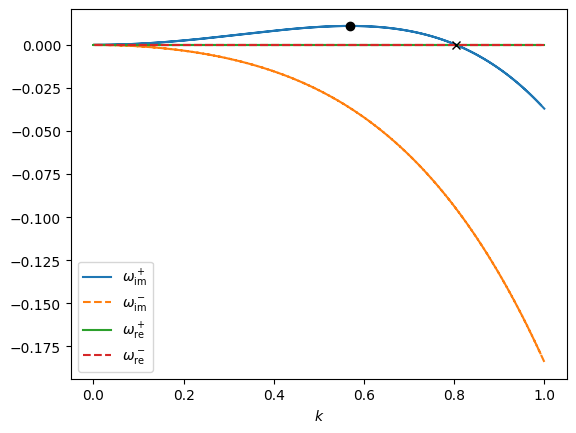

In [3]:
k = np.fft.fftfreq(Nx, d=0.5)
k = np.fft.fftshift(k)
J, Q = build_L_matrices(params)
print(params)
om_plus, om_min  = frequency(k, J, Q)
k_star, r_star = optimize_rate(J, Q, k_bounds=(1e-6, np.max(k)))
freq_root = root(rates, 20, (J,Q))
om_zero = freq_root.x
plt.plot(np.abs(k), om_plus.imag, label = r"$\omega^+_{\rm im}$")
plt.plot(np.abs(k), om_min.imag, "--", label = r"$\omega^-_{\rm im}$")
plt.plot(np.abs(k), om_plus.real, label = r"$\omega^+_{\rm re}$")
plt.plot(np.abs(k), om_min.real, "--",  label = r"$\omega^-_{\rm re}$")
plt.plot(k_star, r_star, "ko" )
plt.plot(om_zero,0, "kx")
plt.legend()
plt.xlabel(r"$k$")
plt.show()


In [4]:
def interpolate_parameter(obs, p0, params, direction = 1, max_it = 400):
    local_param = params.copy()
    local_param[obs] = p0
    J, Q  = build_L_matrices(local_param)
    p_space= [p0]
    k_max, max_rate = optimize_rate(J, Q, k_bounds = (0,1))
    k_space = [k_max]

    converged = False
    while not converged:
        p = p_space[-1]+direction*0.1*k_max**2
        p_space.append(p)
        local_param[obs] = p
        J, Q  = build_L_matrices(local_param)
        k_max, max_rate = optimize_rate(J, Q, k_bounds = (0,1))
        k_space.append(k_max)
        converged = max_rate < 1e-16
        if len(p_space)>max_it:
            break
    return p_space, k_space, converged

In [5]:
D_space = np.linspace(0,0.1,100)
critical_Dvs = []
# params['D_v'] = 0.01
for D in D_space:
    params["D_A"] = D
    params['D_B'] = D
    p_space, k_space, conv = interpolate_parameter("D_v", -0.001, params)  
    if p_space[-2] == -1:
        p_space, k_space, conv = interpolate_parameter("D_v", 1, params,  direction = - 1)  
        critical_Dvs.append(p_space[-2])
    else:
        critical_Dvs.append(p_space[-2])


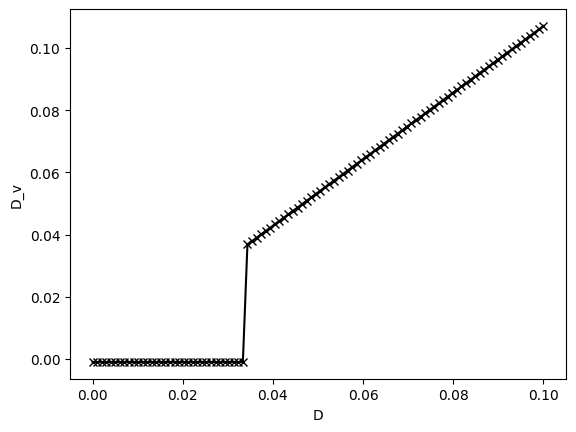

In [6]:
plt.plot(D_space, critical_Dvs, "-kx")
# plt.plot(kab_space, critical_kappas, "-k")
plt.xlabel("D")
plt.ylabel("D_v")
# plt.ylim([-0.025,1.025])
# plt.yscale('log')
plt.show()

In [7]:
import pandas as pd
crit_kab = pd.DataFrame(np.array([D_space, critical_Dvs]).T, columns = ["D", "Dv"])
crit_kab.set_index('Dv', inplace = True)
crit_kab.to_csv("data/critical_Dv_T04.csv")

In [15]:
kab_space = np.concat([np.linspace(-1,0.26,30),np.linspace(0.261,0.297889,25),np.linspace(0.297889,0.33,25),np.linspace(0.331,1,30)])
critical_kappas = []
params['D_v'] = 0.01
for kab in kab_space:
    params["kappa_ab"] = kab
    p_space, k_space, conv = interpolate_parameter("kappa_ba", -1, params)  
    if p_space[-2] == -1:
        p_space, k_space, conv = interpolate_parameter("kappa_ba", 1, params,  direction = - 1)  
        critical_kappas.append(p_space[-2])
    else:
        critical_kappas.append(p_space[-2])


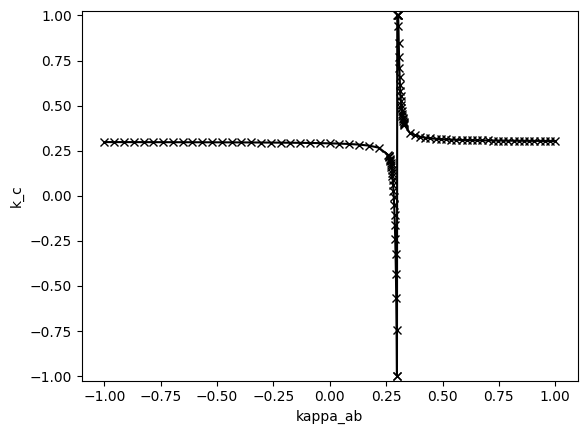

In [16]:
plt.plot(kab_space, critical_kappas, "-kx")
# plt.plot(kab_space, critical_kappas, "-k")
plt.xlabel("kappa_ab")
plt.ylabel("k_c")
plt.ylim([-1.025,1.025])
# plt.yscale('log')
plt.show()

In [20]:
np.array(kab_space)

array([-1.00000000e+00, -9.56551724e-01, -9.13103448e-01, -8.69655172e-01,
       -8.26206897e-01, -7.82758621e-01, -7.39310345e-01, -6.95862069e-01,
       -6.52413793e-01, -6.08965517e-01, -5.65517241e-01, -5.22068966e-01,
       -4.78620690e-01, -4.35172414e-01, -3.91724138e-01, -3.48275862e-01,
       -3.04827586e-01, -2.61379310e-01, -2.17931034e-01, -1.74482759e-01,
       -1.31034483e-01, -8.75862069e-02, -4.41379310e-02, -6.89655172e-04,
        4.27586207e-02,  8.62068966e-02,  1.29655172e-01,  1.73103448e-01,
        2.16551724e-01,  2.60000000e-01,  2.61000000e-01,  2.62537042e-01,
        2.64074083e-01,  2.65611125e-01,  2.67148167e-01,  2.68685208e-01,
        2.70222250e-01,  2.71759292e-01,  2.73296333e-01,  2.74833375e-01,
        2.76370417e-01,  2.77907458e-01,  2.79444500e-01,  2.80981542e-01,
        2.82518583e-01,  2.84055625e-01,  2.85592667e-01,  2.87129708e-01,
        2.88666750e-01,  2.90203792e-01,  2.91740833e-01,  2.93277875e-01,
        2.94814917e-01,  

In [21]:
np.array(critical_kappas)

array([ 0.29788941,  0.29781642,  0.29773822,  0.2976542 ,  0.29756371,
        0.29746594,  0.29736001,  0.29724483,  0.29711914,  0.29698143,
        0.2968299 ,  0.29666236,  0.29647611,  0.29626785,  0.29603343,
        0.29576758,  0.29546355,  0.29511244,  0.29470244,  0.29421734,
        0.29363445,  0.29292088,  0.29202712,  0.29087507,  0.28933387,
        0.28716623,  0.28389284,  0.27837789,  0.26711323,  0.22533212,
        0.22263207,  0.2180224 ,  0.21276771,  0.20675144,  0.19983624,
        0.19186075,  0.18263563,  0.17193938,  0.15951324,  0.14505419,
        0.12820831,  0.10856025,  0.08561927,  0.05880213,  0.02740859,
       -0.00941449, -0.05272347, -0.10385533, -0.16454822, -0.23714044,
       -0.3249164 , -0.43276466, -0.56857672, -0.74676043, -0.99991591,
       -0.99991591,  1.        ,  1.        ,  1.        ,  1.        ,
        0.94232552,  0.84629871,  0.77057691,  0.70933622,  0.65895857,
        0.61701268,  0.58177008,  0.55195098,  0.52657694,  0.50

In [22]:
import pandas as pd
crit_kab = pd.DataFrame(np.array([kab_space, critical_kappas]).T, columns = ["kab", "kba"])
crit_kab.set_index('kba', inplace = True)
crit_kab.to_csv("data/critical_kab_Dv001.csv")

In [34]:
import warnings
from typing import Callable, Iterable

import numpy as np
from scipy.optimize import root_scalar


def multi_root(f: Callable, bracket: Iterable[float], args: Iterable = (), n: int = 30) -> np.ndarray:
    """ Find all roots of f in `bracket`, given that resolution `n` covers the sign change.
    Fine-grained root finding is performed with `scipy.optimize.root_scalar`.
    Parameters
    ----------
    f: Callable
        Function to be evaluated
    bracket: Sequence of two floats
        Specifies interval within which roots are searched.
    args: Iterable, optional
        Iterable passed to `f` for evaluation
    n: int
        Number of points sampled equidistantly from bracket to evaluate `f`.
        Resolution has to be high enough to cover sign changes of all roots but not finer than that.
        Actual roots are found using `scipy.optimize.root_scalar`.
    Returns
    -------
    roots: np.ndarray
        Array containing all unique roots that were found in `bracket`.
    """
    # Evaluate function in given bracket
    x = np.linspace(*bracket, n)
    y = f(x, *args)

    # Find where adjacent signs are not equal
    sign_changes = np.where(np.sign(y[:-1]) != np.sign(y[1:]))[0]

    # Find roots around sign changes
    root_finders = (
        root_scalar(
            f=f,
            args=args,
            bracket=(x[s], x[s+1])
        )
        for s in sign_changes
    )

    roots = np.array([
        r.root if r.converged else np.nan
        for r in root_finders
    ])

    if np.any(np.isnan(roots)):
        warnings.warn("Not all root finders converged for estimated brackets! Maybe increase resolution `n`.")
        roots = roots[~np.isnan(roots)]

    roots_unique = np.unique(roots)
    if len(roots_unique) != len(roots):
        warnings.warn("One root was found multiple times. "
                      "Try to increase or decrease resolution `n` to see if this warning disappears.")

    return roots_unique

In [171]:
from scipy.optimize import root_scalar

# This function will calculate the max rate for given theta and D_v
def objective_Dv(D_v, params):

    # Update the params dictionary with new values for theta and D_v
    params['D_v'] = D_v

    # Calculate the L matrices
    A0, A1 = build_L_matrices(params)

    # Optimize for k to get the max_rate
    result = root(rates, 10, (A0,A1))
    
    # Return the absolute value of the max_rate (we want it close to zero)
    if result.success:
        root_k = result.x[0]
        return root_k**2
    else:
        return D_v

# This function will calculate the max rate for given theta and D_v
def objective(x, params, obs):

    # Update the params dictionary
    params[obs] = x

    # Calculate the L matrices
    J, Q = build_L_matrices(params)

    # Optimize for k to get the max_rate
    result = root_scalar(rates, args =(J, Q), bracket=(1e-12,2), method= 'newton', x0=2)
    # roots = multi_root(rates, bracket=(0,2), args = (J, Q), n = 100)
    
    # Return the absolute value of the max_rate (we want it close to zero)
    if result.converged:
        # root_k = roots[1]
        root_k = result.root
        return - 1/root_k**2
    else:
        return  x**2

# Now we set up the optimization over theta and D_v
def find_critical_value(params, obs, initial_guess=1, bounds = (-1, 1)):

    # Minimize the absolute value of the max_rate (objective function)
    result = minimize_scalar(
        objective,
        initial_guess,
        args=(params,obs),
        bounds=bounds,  # Bounds for parameter
        method='bounded'  # Optimization method
    )

    # Check if the optimization was successful
    if result.success:
        optimal_p = result.x
        return optimal_p, result.fun  # result.fun is the value of the objective function (should be close to 0)
    else:
        raise ValueError("Optimization failed.")



In [172]:
theta = 2/5
kappa_aa = 1 - theta
kappa_bb = 1 - theta
kappa_ab = 0.25
kappa_ba = 0.25
Gamma_aa = 1
Gamma_bb = 1
Gamma_ab = 0
Gamma_ba = 0
A_fixedpoint = 0.35
B_fixedpoint = 0.35
D_A = 0.1
D_B = 0.1
D_v = 0.001
Nx = 256
Ny = 256
Lx = 256
Ly = 256
h = Lx/Nx

params = {
    'D_A': D_A, 'D_B': D_B, 'D_v': D_v,
    'beta': 1.0/D_A, 'h': h,
    'kappa_aa' : kappa_aa, 
    'kappa_bb': kappa_bb,
    'kappa_ab' : kappa_ab,
    'kappa_ba' : kappa_ba,
    'Gamma_aa' : Gamma_aa,
    'Gamma_bb': Gamma_bb,
    'Gamma_ab': Gamma_ab,
    'Gamma_ba': Gamma_ba,
    'a0': A_fixedpoint, 'b0': B_fixedpoint
}

# crit_p, rootksqr = find_critical_value(params,'kappa_ab',1,bounds=(-1,1))

#  print(crit_p,rootksqr)

In [173]:
roots = multi_root(rates, bracket=(0.1,1), args = build_L_matrices(params), n = 50)

In [174]:
params

{'D_A': 0.1,
 'D_B': 0.1,
 'D_v': 0.001,
 'beta': 10.0,
 'h': 1.0,
 'kappa_aa': 0.6,
 'kappa_bb': 0.6,
 'kappa_ab': 0.25,
 'kappa_ba': 0.25,
 'Gamma_aa': 1,
 'Gamma_bb': 1,
 'Gamma_ab': 0,
 'Gamma_ba': 0,
 'a0': 0.35,
 'b0': 0.35}

{'D_A': 0.1, 'D_B': 0.1, 'D_v': 0.001, 'beta': 10.0, 'h': 1.0, 'kappa_aa': 0.6, 'kappa_bb': 0.6, 'kappa_ab': -0.4, 'kappa_ba': -0.4, 'Gamma_aa': 1, 'Gamma_bb': 1, 'Gamma_ab': 0, 'Gamma_ba': 0, 'a0': 0.35, 'b0': 0.35}


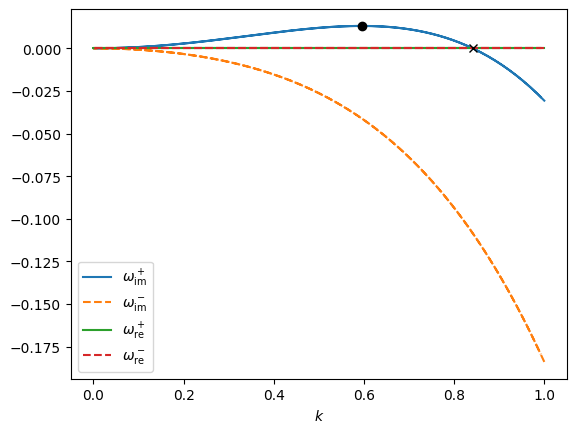

In [185]:
theta = 2/5
kappa_aa = 1 - theta
kappa_bb = 1 - theta
kappa_ab = -theta
kappa_ba = -theta
Gamma_aa = 1
Gamma_bb = 1
Gamma_ab = 0
Gamma_ba = 0
A_fixedpoint = 0.35
B_fixedpoint = 0.35
D_A = 0.1
D_B = 0.1
D_v = 0.001
params = {
    'D_A': D_A, 'D_B': D_B, 'D_v': D_v,
    'beta': 1.0/D_A, 'h': h,
    'kappa_aa' : kappa_aa, 
    'kappa_bb': kappa_bb,
    'kappa_ab' : kappa_ab,
    'kappa_ba' : kappa_ba,
    'Gamma_aa' : Gamma_aa,
    'Gamma_bb': Gamma_bb,
    'Gamma_ab': Gamma_ab,
    'Gamma_ba': Gamma_ba,
    'a0': A_fixedpoint, 'b0': B_fixedpoint
}

k = np.fft.fftfreq(Nx, d=0.5)
k = np.fft.fftshift(k)
J, Q = build_L_matrices(params)
print(params)
om_plus, om_min  = frequency(k, J, Q)
k_star, r_star = optimize_rate(J, Q, k_bounds=(1e-6, np.max(k)))
freq_root = root(rates, 20, (J,Q))
om_zero = freq_root.x
plt.plot(np.abs(k), om_plus.imag, label = r"$\omega^+_{\rm im}$")
plt.plot(np.abs(k), om_min.imag, "--", label = r"$\omega^-_{\rm im}$")
plt.plot(np.abs(k), om_plus.real, label = r"$\omega^+_{\rm re}$")
plt.plot(np.abs(k), om_min.real, "--",  label = r"$\omega^-_{\rm re}$")
plt.plot(k_star, r_star, "ko" )
plt.plot(om_zero,0, "kx")
plt.legend()
plt.xlabel(r"$k$")
plt.show()


In [186]:
freq_root

 message: The solution converged.
 success: True
  status: 1
     fun: [ 5.204e-16]
       x: [ 8.412e-01]
  method: hybr
    nfev: 27
    fjac: [[-1.000e+00]]
       r: [-1.250e-01]
     qtf: [-1.066e-10]

In [183]:
crit_p, rootksqr = find_critical_value(params,'D_v',0.1,bounds=(0,1))
print(crit_p, rootksqr)


0.675563002308682 -4320581072042272.0


In [184]:
params

{'D_A': 0.1,
 'D_B': 0.1,
 'D_v': np.float64(0.67555965895513),
 'beta': 10.0,
 'h': 1.0,
 'kappa_aa': 0.6,
 'kappa_bb': 0.6,
 'kappa_ab': -0.4,
 'kappa_ba': -0.4,
 'Gamma_aa': 1,
 'Gamma_bb': 1,
 'Gamma_ab': 0,
 'Gamma_ba': 0,
 'a0': 0.35,
 'b0': 0.35}

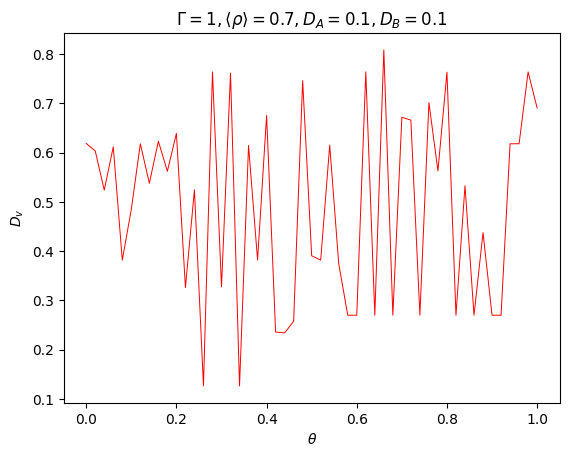

In [187]:
theta_space = np.linspace(0,1,51)
critical_DVs = np.zeros(51)
params["D_v"] = 0
params['a0'] = 0.35
params['b0'] = 0.35

for i, theta in enumerate(theta_space):
    params['kappa_aa'] = 1 - theta
    params['kappa_bb'] = 1 - theta
    params['kappa_ab'] = - theta
    params['kappa_ba'] = - theta
    crit_Dv, rootksqr = find_critical_value(params, obs='D_v', bounds= (0,1))
    critical_DVs[i] = crit_Dv
    params["D_v"] = crit_Dv

title = rf"$\Gamma = 1, \langle \rho \rangle = {params['a0']+params['b0']}, D_A = {D_A}, D_B = {D_B} $"
plt.plot(theta_space, critical_DVs, 'r', lw= 0.7)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$D_v$")
plt.title(title)
# plt.ylim([0.,1])
plt.show()

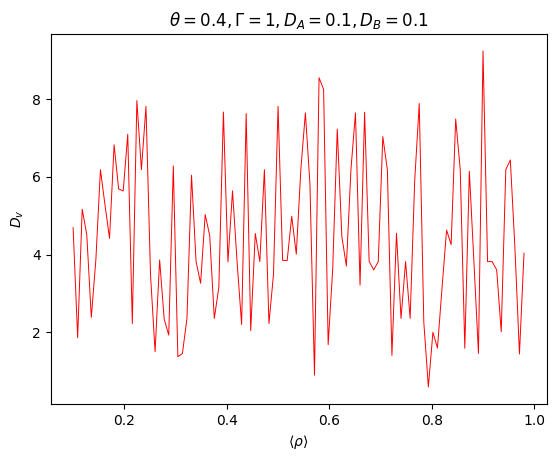

In [ ]:
rho0_space = np.linspace(0.1,0.98,100)
critical_DVs = np.zeros(100)
theta = 2/5
params['kappa_aa'] = 1 - theta
params['kappa_bb'] = 1 - theta
params['kappa_ab'] = - theta
params['kappa_ba'] = - theta
params["D_v"] = 0
for i, rho0 in enumerate(rho0_space):
    params['a0'] = rho0/2
    params['b0'] = rho0/2
    crit_Dv, rootksqr = find_critical_value(params, )
    critical_DVs[i] = crit_Dv
    params["D_v"] = crit_Dv

title = rf"$\theta = {theta}, \Gamma = 1, D_A = {D_A}, D_B = {D_B} $"
plt.plot(rho0_space, critical_DVs, 'r', lw= 0.7)
plt.xlabel(r"$\langle \rho \rangle$")
plt.ylabel(r"$D_v$")
plt.title(title)
# plt.ylim([0.,1])
plt.show()

In [10]:
critical_DVs

array([6.36344463e-06, 6.36344463e-06, 6.36344463e-06, 6.36344463e-06,
       6.36344463e-06, 6.36344463e-06, 6.36344463e-06, 6.36344463e-06,
       6.36344463e-06, 6.36344463e-06, 6.36344463e-06, 6.36344463e-06,
       1.27941321e-02, 2.83037315e-02, 4.22297003e-02, 5.47593604e-02,
       6.60428231e-02, 7.62113200e-02, 8.53825841e-02, 9.36535446e-02,
       1.01110755e-01, 1.07824899e-01, 1.13875607e-01, 1.19309233e-01,
       1.24181710e-01, 1.28540785e-01, 1.32428629e-01, 1.35878661e-01,
       1.38930951e-01, 1.41606782e-01, 1.43937419e-01, 1.45947733e-01,
       1.47660214e-01, 1.49094954e-01, 1.50269916e-01, 1.51196671e-01,
       1.51902672e-01, 1.52392402e-01, 1.52681852e-01, 1.52785053e-01,
       1.52706415e-01, 1.52463956e-01, 1.52062023e-01, 1.51511222e-01,
       1.50823990e-01, 1.49997911e-01, 1.49046969e-01, 1.47975098e-01,
       1.46791556e-01, 1.45499084e-01, 1.44102978e-01, 1.42609487e-01,
       1.41018714e-01, 1.39343125e-01, 1.37581089e-01, 1.35740666e-01,
      

In [11]:
rho0_space

array([0.1       , 0.10888889, 0.11777778, 0.12666667, 0.13555556,
       0.14444444, 0.15333333, 0.16222222, 0.17111111, 0.18      ,
       0.18888889, 0.19777778, 0.20666667, 0.21555556, 0.22444444,
       0.23333333, 0.24222222, 0.25111111, 0.26      , 0.26888889,
       0.27777778, 0.28666667, 0.29555556, 0.30444444, 0.31333333,
       0.32222222, 0.33111111, 0.34      , 0.34888889, 0.35777778,
       0.36666667, 0.37555556, 0.38444444, 0.39333333, 0.40222222,
       0.41111111, 0.42      , 0.42888889, 0.43777778, 0.44666667,
       0.45555556, 0.46444444, 0.47333333, 0.48222222, 0.49111111,
       0.5       , 0.50888889, 0.51777778, 0.52666667, 0.53555556,
       0.54444444, 0.55333333, 0.56222222, 0.57111111, 0.58      ,
       0.58888889, 0.59777778, 0.60666667, 0.61555556, 0.62444444,
       0.63333333, 0.64222222, 0.65111111, 0.66      , 0.66888889,
       0.67777778, 0.68666667, 0.69555556, 0.70444444, 0.71333333,
       0.72222222, 0.73111111, 0.74      , 0.74888889, 0.75777

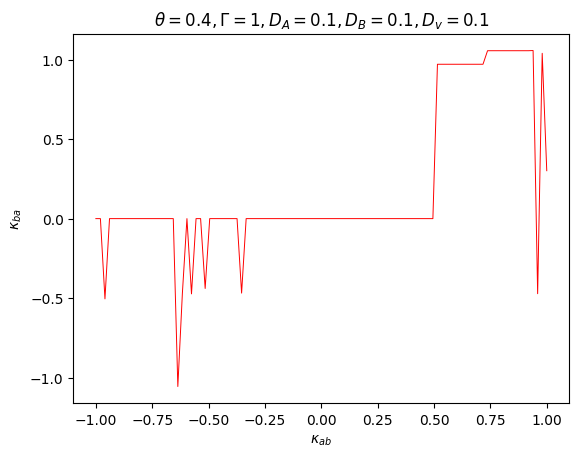

In [49]:
kab_space = np.linspace(-1,1,100)
critical_ks = np.zeros(100)
theta = 2/5
params['kappa_aa'] = 1 - theta
params['kappa_bb'] = 1 - theta
for i, kab in enumerate(kab_space):
    params['kappa_ab'] = kab

    crit_kba, rootksqr = find_critical_value(params, obs='kappa_ba', initial_guess = 0, bounds = (-2,2))
    critical_ks[i] = crit_kba

title = rf"$\theta = {theta}, \Gamma = 1, D_A = {D_A}, D_B = {D_B}, D_v = {D_v} $"
plt.plot(kab_space, critical_ks, 'r', lw= 0.7)
plt.xlabel(r"$\kappa_{ab}$")
plt.ylabel(r"$\kappa_{ba}$")
plt.title(title)
# plt.ylim([0.,1])
plt.show()